# SVM Sleep Classification

Support Vector Machine (linear kernel) to classify Wake, NREM, and REM

Linear SVM is the most common SVM variant in automated classification of sleep state research due to interpretable decision boundaries and strong performance on log-transformed spectral features

Running leave-one-mouse-out CV on all 29 EXP1 mice.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef
)
sys.path.insert(0, os.path.abspath('..'))
from pyecog2.convert_figshare_sleep_data import readbinary_dat

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

In [3]:
def extract_power(power_spectra):
    """Sum power within each EEG frequency band (Hubbard & Franken 2020)."""
    bands = {
        'delta1':       (0.75,  1.75),
        'delta2':       (2.5,   3.5),
        'theta':        (6.0,   9.0),
        'sigma':        (10.0, 15.0),
        'beta_lowgamma':(18.0, 45.0)
    }
    result = {}
    for name, (lo, hi) in bands.items():
        result[name] = power_spectra[:, int(lo/0.25):int(hi/0.25)].sum(axis=1)
    return result

In [4]:
def load_data(dat_file):
    scores, power_spectra, eeg_var, emg_var, _ = readbinary_dat(dat_file)

    artifact_map = {'1': 'w', '2': 'n', '3': 'r'}
    states = np.array([artifact_map.get(s, s) for s in scores])

    bands = extract_power(power_spectra)
    df = pd.DataFrame({'state': states, 'eeg_variance': eeg_var, 'emg_variance': emg_var, **bands})

    power_cols = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma', 'eeg_variance', 'emg_variance']
    df[power_cols] = np.log(df[power_cols].clip(lower=1e-30))
    df['delta2_delta1_ratio'] = df['delta2'] - df['delta1']

    return df[df['state'].isin(['w', 'n', 'r'])].reset_index(drop=True)

In [6]:
dat_files = sorted(glob.glob('data/M*EXP1.dat'))
mouse_dfs = {}
for dat_file in dat_files:
    mouse_id = os.path.splitext(os.path.basename(dat_file))[0]
    mouse_dfs[mouse_id] = load_data(dat_file)

2. Features

| Feature | Description |
|---|---|
| delta1 | Slow delta (0.75–1.75 Hz) and logged |
| delta2 | Fast delta (2.5–3.5 Hz), homeostatic sleep marker |
| theta | Theta (6–9 Hz), higher in REM |
| sigma | Sigma (10–15 Hz), sleep spindles (for NREM) |
| beta_lowgamma | Beta/low-gamma (18–45 Hz), higher in Wake |
| eeg_variance | Total EEG signal variance |
| emg_variance | EMG variance, muscle activity so higher when awake |
| delta2_delta1_ratio | Sleep pressure |

In [7]:
FEATURES = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma',
            'eeg_variance', 'emg_variance', 'delta2_delta1_ratio']
LABEL = 'state'

list(mouse_dfs.values())[0][FEATURES + [LABEL]].head()

,delta1,delta2,theta,sigma,beta_lowgamma,eeg_variance,emg_variance,delta2_delta1_ratio,state
0,-11.036003,-9.640248,-9.441095,-10.525328,-9.498915,-19.243517,-21.908051,1.395755,w
1,-10.712376,-8.614235,-9.206966,-9.347326,-9.661184,-18.827913,-23.035021,2.098141,w
2,-10.915536,-9.111667,-9.756100,-10.122412,-9.549077,-19.264603,-23.332449,1.803869,w
3,-9.665816,-9.770272,-8.751550,-9.986262,-9.345723,-18.767168,-23.324778,-0.104456,n
4,-9.599375,-8.270100,-9.492494,-9.046444,-9.287940,-18.817999,-23.422405,1.329275,n


3. Leave-one-out CV

for each mouse we train on all others and predict on the left out mouse

Pipeline(StandardScaler → LinearSVC) is used so the scaler is fit only on training data each fold, helps prevent leaks

class_weight='balanced' adjusts for the Wake/NREM/REM imbalance, same as for RF

In [14]:
mouse_ids = list(mouse_dfs.keys())
results = []
all_y_true = []
all_y_pred = []

In [22]:
for test_mouse in mouse_ids:
    train_mice = [m for m in mouse_ids if m != test_mouse]

    train_df = pd.concat([mouse_dfs[m] for m in train_mice], ignore_index=True)
    test_df  = mouse_dfs[test_mouse]

    X_train = train_df[FEATURES].values
    y_train = train_df[LABEL].values
    X_test  = test_df[FEATURES].values
    y_test  = test_df[LABEL].values

    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=7))
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    results.append({'mouse': test_mouse, 'balanced_accuracy': bal_acc})
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    print(f'{test_mouse}: balanced accuracy = {bal_acc:.3f}')

M10EXP1: balanced accuracy = 0.868
M11EXP1: balanced accuracy = 0.899
M12EXP1: balanced accuracy = 0.928
M13EXP1: balanced accuracy = 0.773
M14EXP1: balanced accuracy = 0.885
M15EXP1: balanced accuracy = 0.772
M16EXP1: balanced accuracy = 0.829
M17EXP1: balanced accuracy = 0.773
M18EXP1: balanced accuracy = 0.701
M19EXP1: balanced accuracy = 0.884
M1EXP1: balanced accuracy = 0.911
M20EXP1: balanced accuracy = 0.908
M21EXP1: balanced accuracy = 0.763
M22EXP1: balanced accuracy = 0.824
M23EXP1: balanced accuracy = 0.863
M24EXP1: balanced accuracy = 0.884
M25EXP1: balanced accuracy = 0.745
M26EXP1: balanced accuracy = 0.883
M27EXP1: balanced accuracy = 0.919
M28EXP1: balanced accuracy = 0.872
M29EXP1: balanced accuracy = 0.702
M2EXP1: balanced accuracy = 0.910
M3EXP1: balanced accuracy = 0.897
M4EXP1: balanced accuracy = 0.392
M5EXP1: balanced accuracy = 0.917
M6EXP1: balanced accuracy = 0.820
M7EXP1: balanced accuracy = 0.800
M8EXP1: balanced accuracy = 0.917
M9EXP1: balanced accuracy = 

4. Results

Mean balanced accuracy: 0.831 ± 0.108


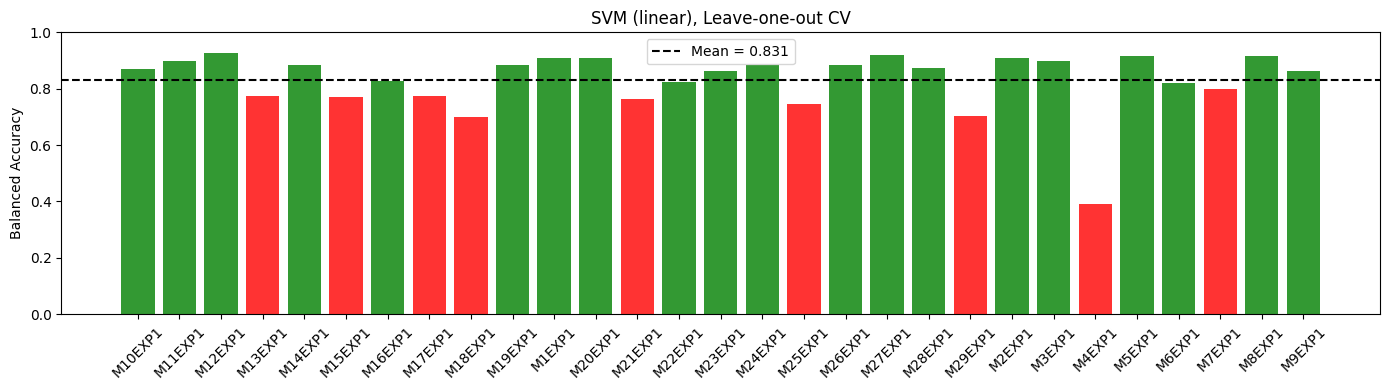

In [23]:
results_df = pd.DataFrame(results)
print(f'Mean balanced accuracy: {results_df["balanced_accuracy"].mean():.3f} '
      f'± {results_df["balanced_accuracy"].std():.3f}')

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['red' if v < 0.8 else 'green' for v in results_df['balanced_accuracy']]
ax.bar(results_df['mouse'], results_df['balanced_accuracy'], color=colors, alpha=0.8)
ax.axhline(results_df['balanced_accuracy'].mean(), color='black', linestyle='--',
           label=f'Mean = {results_df["balanced_accuracy"].mean():.3f}')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('SVM (linear), Leave-one-out CV')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

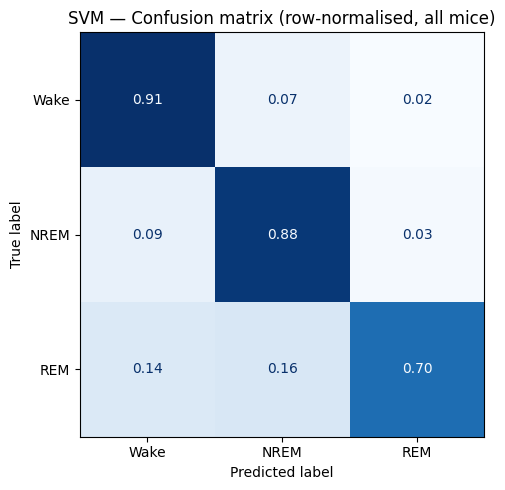

In [14]:
labels = ['w', 'n', 'r']
label_names = ['Wake', 'NREM', 'REM']

cm = confusion_matrix(all_y_true, all_y_pred, labels=labels, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title('SVM — Confusion matrix (row-normalised, all mice)')
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(all_y_true, all_y_pred, labels=labels, target_names=label_names))
kappa = cohen_kappa_score(all_y_true, all_y_pred)
mcc = matthews_corrcoef(all_y_true, all_y_pred)
print(f"Cohen's kappa: {kappa:.4f}  MCC: {mcc:.4f}")

              precision    recall  f1-score   support

        Wake       0.93      0.91      0.92   1421943
        NREM       0.87      0.88      0.88    948297
         REM       0.62      0.70      0.66    135360

    accuracy                           0.89   2505600
   macro avg       0.81      0.83      0.82   2505600
weighted avg       0.89      0.89      0.89   2505600

Cohen's kappa: 0.7895  MCC: 0.7896


Linear SVM learns one weight vector per class. 
The magnitude of each weight reflects how much that feature contributes to separating that class from the others.

Trained on all mice together for stable estimates.

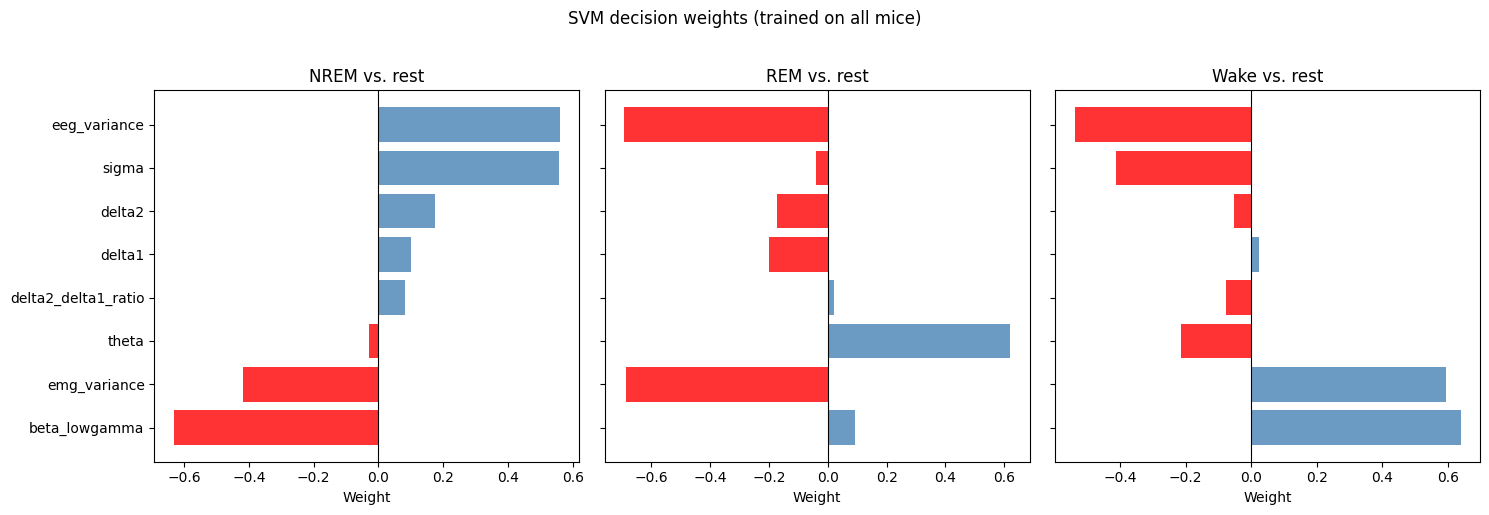

In [16]:
all_df = pd.concat(mouse_dfs.values(), ignore_index=True)

clf_full = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=7))
])
clf_full.fit(all_df[FEATURES], all_df[LABEL])

svm = clf_full.named_steps['svm']
classes = svm.classes_
class_labels = {'n': 'NREM', 'r': 'REM', 'w': 'Wake'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, cls, coefs in zip(axes, classes, svm.coef_):
    order = np.argsort(coefs)
    colors = ['red' if c < 0 else 'steelblue' for c in coefs[order]]
    ax.barh([FEATURES[i] for i in order], coefs[order], color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{class_labels[cls]} vs. rest')
    ax.set_xlabel('Weight')

plt.suptitle('SVM decision weights (trained on all mice)', y=1.02)
plt.tight_layout()
plt.show()

# M4EXP1 analysis

M4EXP1 got a 0.392 balanced accuracy, big outlier compared to the mean of 0.853.

In [18]:
# Re-run SVM for M4EXP1 to get its individual predictions
train_mice_m4 = [m for m in mouse_ids if m != 'M4EXP1']
train_df_m4 = pd.concat([mouse_dfs[m] for m in train_mice_m4], ignore_index=True)

clf_m4 = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=7))
])
clf_m4.fit(train_df_m4[FEATURES].values, train_df_m4[LABEL].values)
y_pred_m4 = clf_m4.predict(m4[FEATURES].values)
y_true_m4 = m4[LABEL].values

In [19]:
print("M4EXP1 classification report:")
print(classification_report(y_true_m4, y_pred_m4, labels=['w','n','r'], target_names=['Wake','NREM','REM']))

M4EXP1 classification report:
              precision    recall  f1-score   support

        Wake       0.55      1.00      0.71     43790
        NREM       0.98      0.18      0.30     38264
         REM       1.00      0.00      0.00      4346

    accuracy                           0.58     86400
   macro avg       0.84      0.39      0.34     86400
weighted avg       0.76      0.58      0.49     86400



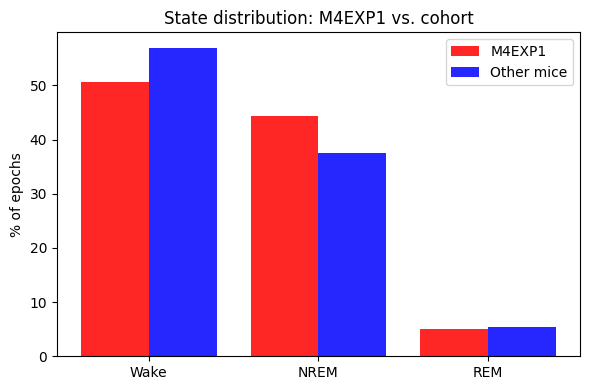

In [36]:
m4 = mouse_dfs['M4EXP1']
cohort_excl_m4 = pd.concat([df for k, df in mouse_dfs.items() if k != 'M4EXP1'], ignore_index=True)

m4_counts  = m4['state'].value_counts().reindex(['w','n','r'], fill_value=0)
all_counts = cohort_excl_m4['state'].value_counts().reindex(['w','n','r'], fill_value=0)

x = np.arange(3)
labels_plot = ['Wake', 'NREM', 'REM']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x-0.2, m4_counts.values / len(m4) * 100, width=0.4, label='M4EXP1', color='red', alpha=0.85)
ax.bar(x+0.2, all_counts.values / len(cohort_excl_m4) * 100, width=0.4, label='Other mice', color='blue', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot)
ax.set_ylabel('% of epochs')
ax.set_title('State distribution: M4EXP1 vs. cohort')
ax.legend()
plt.tight_layout()
plt.show()

the low accuracy doesn't seem to be by a widely missing sleep state as the  state distribution is normal compared to the other mouses.

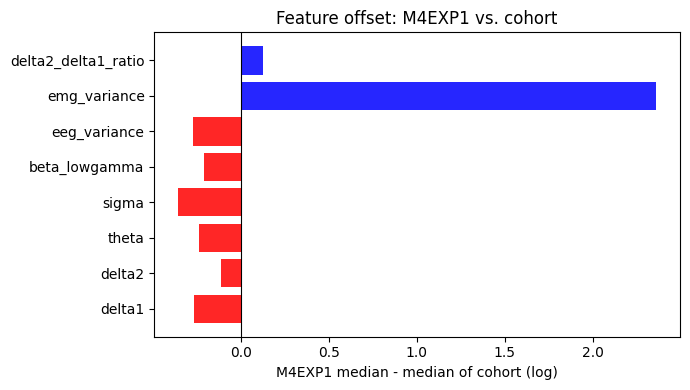

In [50]:
m4_med  = m4[FEATURES].median()
all_med = cohort_excl_m4[FEATURES].median()
diff    = m4_med - all_med
colours  = ['red' if v < 0 else 'blue' for v in diff]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(FEATURES, diff, color=colours, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('M4EXP1 median - median of cohort (log)')
ax.set_title('Feature offset: M4EXP1 vs. cohort')
plt.tight_layout()
plt.show()

Several features in M4EXP1 are shifted in comparison to the cohort median.
The SVM is trained on the other 28 mice, so a large feature offset means it's encountering unfamiliar values when testing (pushing M4EXP1 epochs past the wrong decision boundaries)

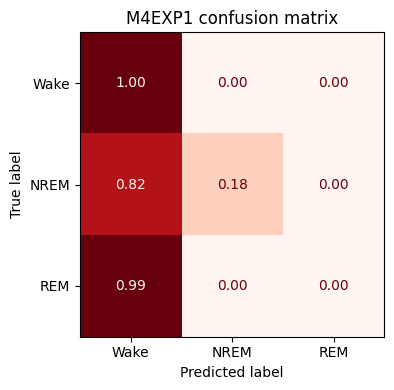

In [ ]:
cm_m4 = confusion_matrix(y_true_m4, y_pred_m4, labels=['w','n','r'], normalize='true')
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_m4, display_labels=['Wake','NREM','REM'])
disp.plot(ax=ax, colorbar=False, cmap='Reds', values_format='.2f')
ax.set_title('M4EXP1 confusion matrix')
plt.tight_layout()
plt.show()

# REM Confusion Analysis

REM has the lowest per-class performance (precision 0.62, recall 0.70, F1 0.66) so breaking down which states REM is being confused with.

In [39]:
pred_df = pd.concat(
    [mouse_dfs[m].assign(mouse=m) for m in mouse_ids],
    ignore_index=True
)
pred_df['y_pred'] = all_y_pred
true_rem = pred_df[pred_df['state'] =='r']
pred_as_rem = pred_df[pred_df['y_pred'] =='r']
rem_correct = true_rem[true_rem['y_pred'] =='r']
rem_fn_nrem = true_rem[true_rem['y_pred'] =='n']
rem_fn_wake = true_rem[true_rem['y_pred'] =='w']
rem_fp_nrem = pred_as_rem[pred_as_rem['state'] =='n']
rem_fp_wake = pred_as_rem[pred_as_rem['state'] =='w']

n_rem = len(true_rem)
n_pred = len(pred_as_rem)

In [51]:
print(f"True REM epochs: {n_rem:,}")
print(f"Correctly classified: {len(rem_correct):,} ({100*len(rem_correct)/n_rem:.1f}%)")
print(f"Missed as NREM: {len(rem_fn_nrem):,} ({100*len(rem_fn_nrem)/n_rem:.1f}%)")
print(f"Missed as Wake: {len(rem_fn_wake):,} ({100*len(rem_fn_wake)/n_rem:.1f}%)")

True REM epochs: 135,360
Correctly classified: 94,651 (69.9%)
Missed as NREM: 21,358 (15.8%)
Missed as Wake: 19,351 (14.3%)


In [40]:
print(f"Predicted REM epochs: {n_pred:,}")
print(f"True positives: {len(rem_correct):,} ({100*len(rem_correct)/n_pred:.1f}%)")
print(f"False positives from NREM: {len(rem_fp_nrem):,} ({100*len(rem_fp_nrem)/n_pred:.1f}%)")
print(f"False positives from Wake: {len(rem_fp_wake):,} ({100*len(rem_fp_wake)/n_pred:.1f}%)")

Predicted REM epochs: 151,989
True positives: 94,651 (62.3%)
False positives from NREM: 29,057 (19.1%)
False positives from Wake: 28,281 (18.6%)


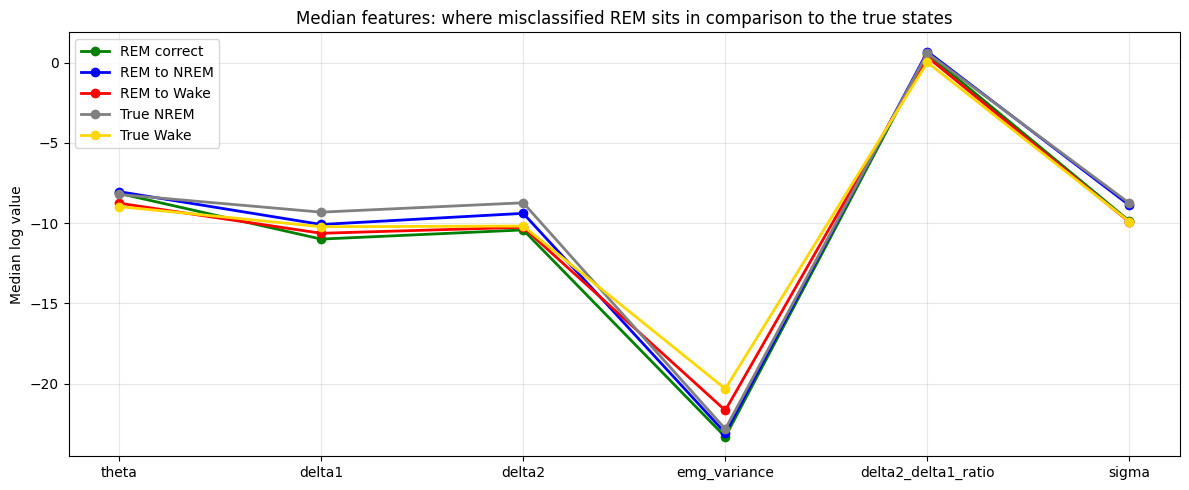

In [ ]:
true_nrem = pred_df[(pred_df['state'] == 'n') & (pred_df['y_pred'] == 'n')]
true_wake = pred_df[(pred_df['state'] == 'w') & (pred_df['y_pred'] == 'w')]

comparison = pd.DataFrame({
    'REM correct': rem_correct[key_features].median(),
    'REM to NREM': rem_fn_nrem[key_features].median() if len(rem_fn_nrem) > 0 else np.nan,
    'REM to Wake': rem_fn_wake[key_features].median() if len(rem_fn_wake) > 0 else np.nan,
    'True NREM': true_nrem[key_features].median(), 
    'True Wake': true_wake[key_features].median()
})

x = np.arange(len(key_features))
group_colours = {
    'REM correct':'green',
    'REM to NREM':'blue',
    'REM to Wake':'red',
    'True NREM': 'grey',
    'True Wake': 'gold'
    }

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in group_colours.items():
    ax.plot(x, comparison[col], marker='o', label=col, color=color, linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(key_features)
ax.set_ylabel('Median log value')
ax.set_title('Median features: where misclassified REM sits in comparison to the true states')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()